In [1]:
!pip install opencv-python ultralytics easyocr Pillow numpy

In [2]:
import cv2
from ultralytics import YOLO
import easyocr
from PIL import Image
import numpy as np

# Initialize EasyOCR reader
reader = easyocr.Reader(['en'], gpu=False)

# Load your YOLO model (replace with your model's path)
model = YOLO('yolov8n.pt', task='detect')

# Open the video file (replace with your video file path)
video_path = 'test.mp4'
cap = cv2.VideoCapture(video_path)

# Create a VideoWriter object (optional, if you want to save the output)
output_path = 'output_video.mp4'
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, 30.0, (640, 480))  # Adjust frame size if necessary


0: 480x640 11 persons, 4 cars, 5 motorcycles, 1 truck, 168.6ms
Speed: 4.4ms preprocess, 168.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


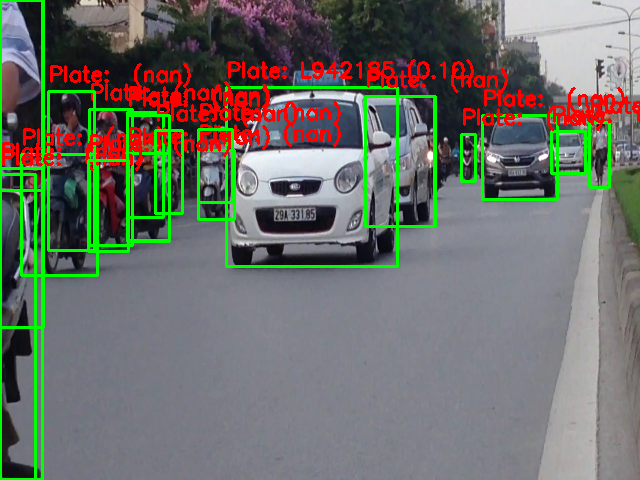


0: 480x640 8 persons, 2 bicycles, 3 cars, 1 truck, 189.3ms
Speed: 1.6ms preprocess, 189.3ms inference, 7.8ms postprocess per image at shape (1, 3, 480, 640)


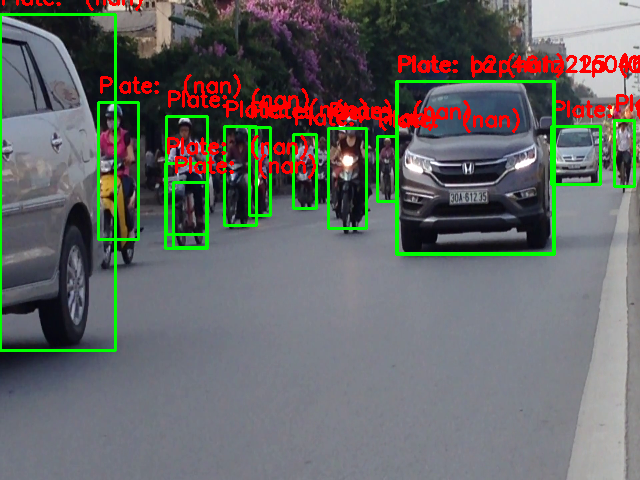


0: 480x640 14 persons, 2 bicycles, 2 cars, 5 motorcycles, 242.9ms
Speed: 1.6ms preprocess, 242.9ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


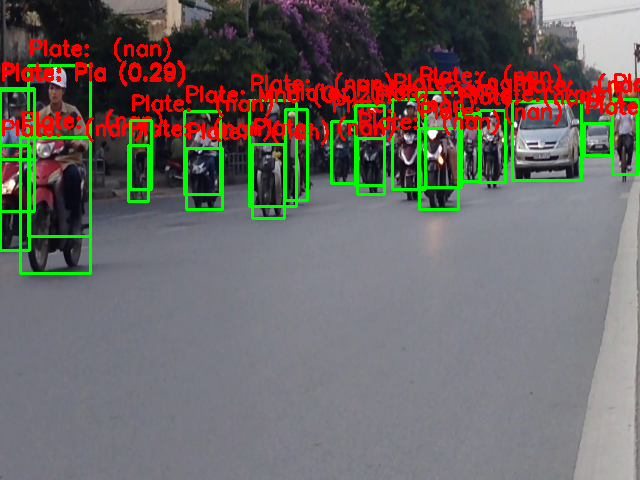


0: 480x640 8 persons, 3 bicycles, 3 cars, 3 motorcycles, 119.0ms
Speed: 1.8ms preprocess, 119.0ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


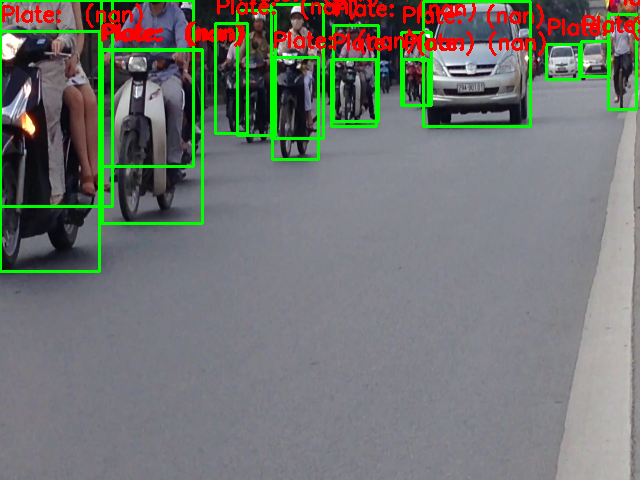


0: 480x640 11 persons, 3 cars, 3 motorcycles, 1 truck, 1 handbag, 116.2ms
Speed: 1.5ms preprocess, 116.2ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


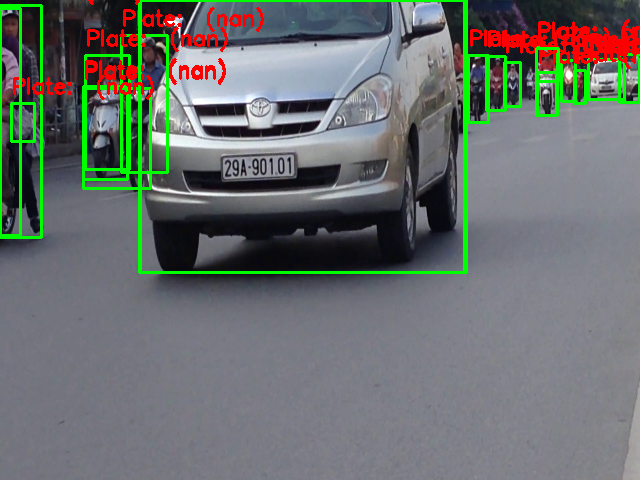


0: 480x640 9 persons, 2 bicycles, 2 cars, 4 motorcycles, 115.5ms
Speed: 1.4ms preprocess, 115.5ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


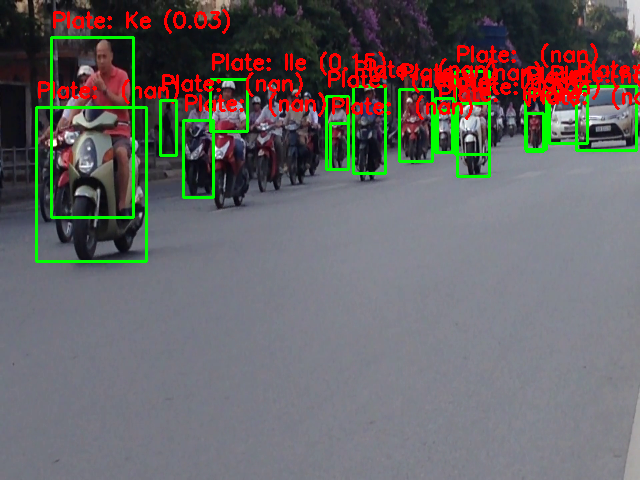


0: 480x640 10 persons, 3 cars, 6 motorcycles, 124.3ms
Speed: 2.6ms preprocess, 124.3ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


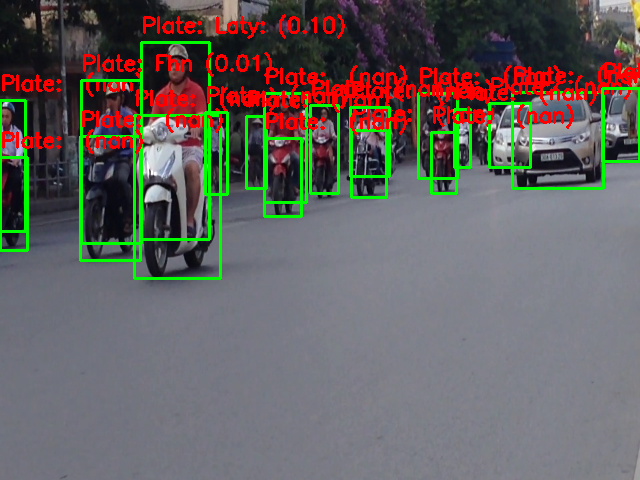


0: 480x640 9 persons, 3 bicycles, 3 cars, 3 motorcycles, 128.9ms
Speed: 1.5ms preprocess, 128.9ms inference, 0.8ms postprocess per image at shape (1, 3, 480, 640)


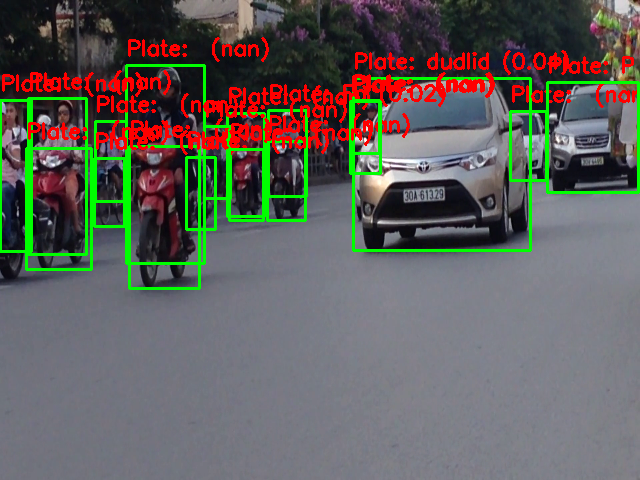


0: 480x640 6 persons, 2 cars, 2 motorcycles, 132.2ms
Speed: 1.7ms preprocess, 132.2ms inference, 0.7ms postprocess per image at shape (1, 3, 480, 640)


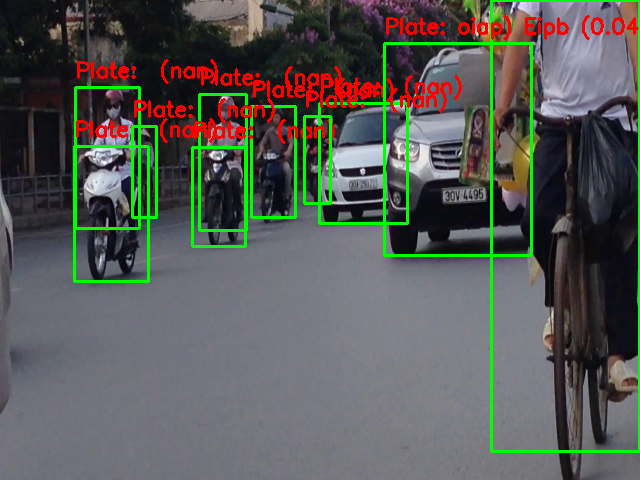


0: 480x640 6 persons, 1 bicycle, 2 cars, 2 motorcycles, 1 truck, 134.8ms
Speed: 1.8ms preprocess, 134.8ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 640)


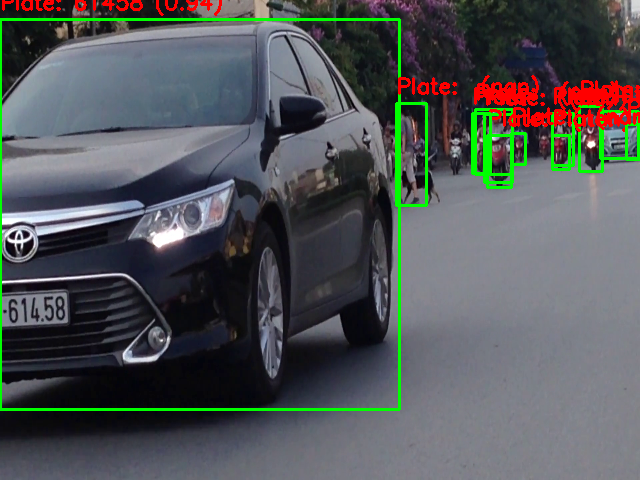


0: 480x640 12 persons, 3 bicycles, 2 cars, 3 motorcycles, 185.6ms
Speed: 1.5ms preprocess, 185.6ms inference, 1.0ms postprocess per image at shape (1, 3, 480, 640)


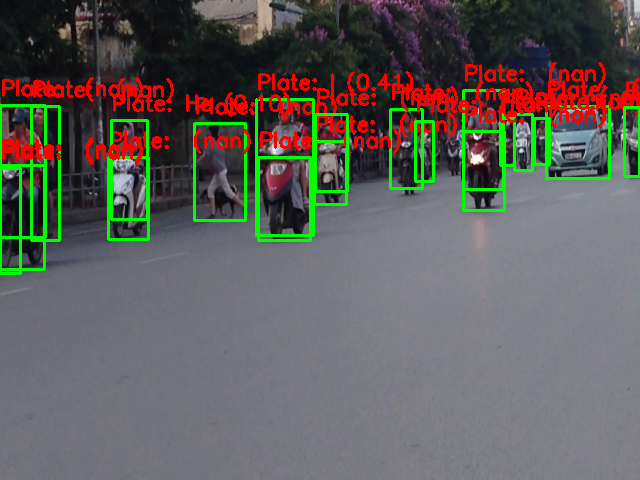

In [3]:
# Frame skipping factor (adjust as needed for performance)
frame_skip = 80  # Skip every 3rd frame
frame_count = 0

from google.colab.patches import cv2_imshow # Import cv2_imshow

while cap.isOpened():
    ret, frame = cap.read()  # Read a frame from the video
    if not ret:
        break  # Exit loop if there are no frames left

    # Skip frames
    if frame_count % frame_skip != 0:
        frame_count += 1
        continue  # Skip processing this frame

    # Resize the frame (optional, adjust size as needed)
    frame = cv2.resize(frame, (640, 480))  # Resize to 640x480

    # Make predictions on the current frame
    results = model.predict(source=frame)

    # Iterate over results and draw predictions
    for result in results:
        boxes = result.boxes  # Get the boxes predicted by the model
        for box in boxes:
            class_id = int(box.cls)  # Get the class ID
            confidence = box.conf.item()  # Get confidence score
            coordinates = box.xyxy[0]  # Get box coordinates as a tensor

            # Extract and convert box coordinates to integers
            x1, y1, x2, y2 = map(int, coordinates.tolist())  # Convert tensor to list and then to int

            # Draw the box on the frame
            cv2.rectangle(frame, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Draw rectangle

            # Try to apply OCR on detected region
            try:
                # Ensure coordinates are within frame bounds
                r0 = max(0, x1)
                r1 = max(0, y1)
                r2 = min(frame.shape[1], x2)
                r3 = min(frame.shape[0], y2)

                # Crop license plate region
                plate_region = frame[r1:r3, r0:r2]

                # Convert to format compatible with EasyOCR
                plate_image = Image.fromarray(cv2.cvtColor(plate_region, cv2.COLOR_BGR2RGB))
                plate_array = np.array(plate_image)

                # Use EasyOCR to read text from plate
                plate_number = reader.readtext(plate_array)
                concat_number = ' '.join([number[1] for number in plate_number])
                number_conf = np.mean([number[2] for number in plate_number])

                # Draw the detected text on the frame
                cv2.putText(
                    img=frame,
                    text=f"Plate: {concat_number} ({number_conf:.2f})",
                    org=(r0, r1 - 10),
                    fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                    fontScale=0.7,
                    color=(0, 0, 255),
                    thickness=2
                )

            except Exception as e:
                print(f"OCR Error: {e}")
                pass

    # Show the frame with detections
    cv2_imshow(frame) # Use cv2_imshow instead of cv2.imshow

    # Write the frame to the output video (optional)
    out.write(frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break  # Exit loop if 'q' is pressed

    frame_count += 1  # Increment frame count

# Release resources
cap.release()
out.release()  # Release the VideoWriter object if used
cv2.destroyAllWindows()